# OKX Wallet — Analyse des distributions de gas

Analyse des transactions OKX Wallet (EIP-7702, `0x80296ff8d1ed46f8e3c7992664d13b833504c2bb`) depuis `gas.db`.

Métriques analysées :
- Distribution des **priority fees** (`maxPriorityFeePerGas`)
- Distribution du **fee factor** (`(maxFee - priority) / baseFee` à l'inclusion)
- Distribution du **fee factor parent** (`(maxFee - priority) / baseFee_soumission`)
- Distribution du **gas limit factor** (`gasLimit / estimatedGas`)

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

DB_PATH = Path('..') / 'gas.db'

con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT
        hash, block,
        max_fee_gwei,
        max_priority_gwei,
        base_fee_gwei,
        fee_factor,
        fee_factor_parent,
        gas_limit,
        estimated_gas,
        gas_limit_factor
    FROM transactions
    WHERE wallet = 'OKX Wallet'
      AND tx_type = 2
      AND max_priority_gwei IS NOT NULL
""", con)
con.close()

print(f"Transactions chargées : {len(df):,}")
print(f"Blocs couverts        : {df.block.min():,} → {df.block.max():,}")
df.describe().round(4)

Transactions chargées : 25,125
Blocs couverts        : 24,000,003 → 24,322,985


,block,max_fee_gwei,max_priority_gwei,base_fee_gwei,fee_factor,fee_factor_parent,gas_limit,estimated_gas,gas_limit_factor
count,2.512500e+04,25125.0000,25125.0000,25125.0000,25125.0000,25125.0000,2.512500e+04,2.484000e+04,24840.0000
mean,2.413322e+07,0.9583,0.4418,0.0542,12.3194,12.4102,3.560207e+05,2.538378e+05,1.7611
std,1.086094e+05,6.6641,0.6530,0.0479,174.2558,176.2886,9.721791e+05,7.835242e+05,7.3163
min,2.400000e+07,0.0256,0.0000,0.0196,0.0000,0.0000,2.100000e+04,2.100000e+04,0.0183
25%,2.402208e+07,0.1395,0.0300,0.0332,1.2328,1.2493,6.831000e+04,4.647900e+04,1.2001
50%,2.412229e+07,0.5489,0.5000,0.0398,1.3456,1.3500,1.367360e+05,8.761200e+04,1.5000
75%,2.421072e+07,0.6147,0.5000,0.0525,1.4771,1.4435,3.413260e+05,2.340988e+05,1.5000
max,2.432298e+07,200.0000,50.0000,1.0551,4999.4966,5179.4082,1.677722e+07,1.574706e+07,205.8291


## 1. Distribution des priority fees (`maxPriorityFeePerGas`)

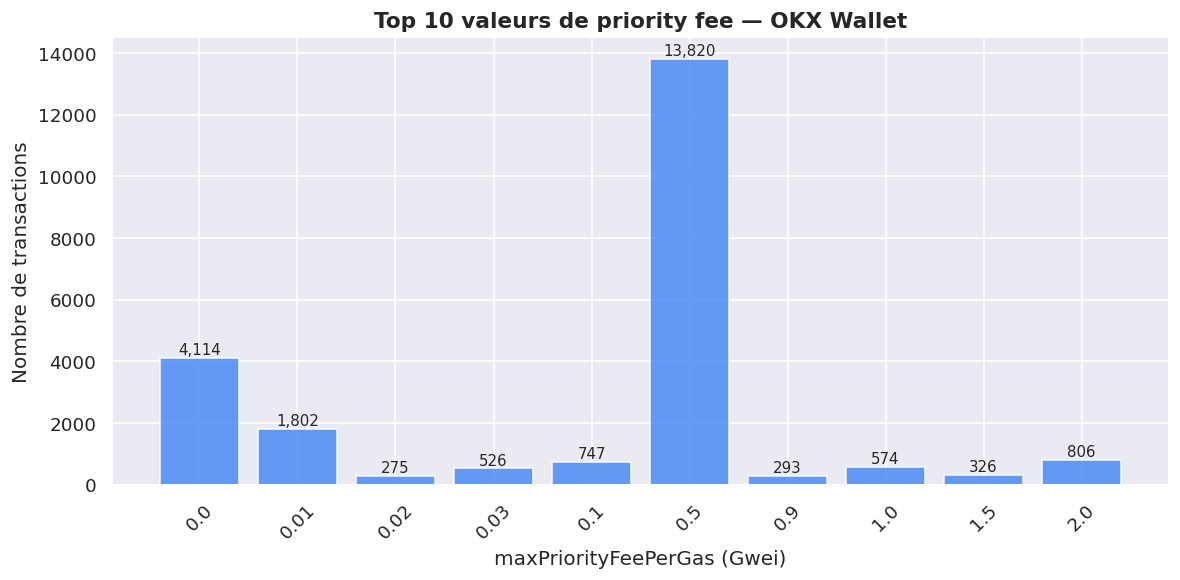


Top 10 valeurs de priority fee (arrondi à 2dp) :
max_priority_gwei
0.50    13820
0.00     4114
0.01     1802
2.00      806
0.10      747
1.00      574
0.03      526
1.50      326
0.90      293
0.02      275


In [2]:
prio = df['max_priority_gwei'].dropna()

top_prio = prio.round(2).value_counts().head(10).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_prio.index.astype(str), top_prio.values, color='#4C8BF5', alpha=0.85)
ax.set_title('Top 10 valeurs de priority fee — OKX Wallet', fontsize=13, fontweight='bold')
ax.set_xlabel('maxPriorityFeePerGas (Gwei)')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_prio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 valeurs de priority fee (arrondi à 2dp) :")
print(prio.round(2).value_counts().head(10).to_string())

## 2. Distribution du fee factor à l'inclusion (`fee_factor`)

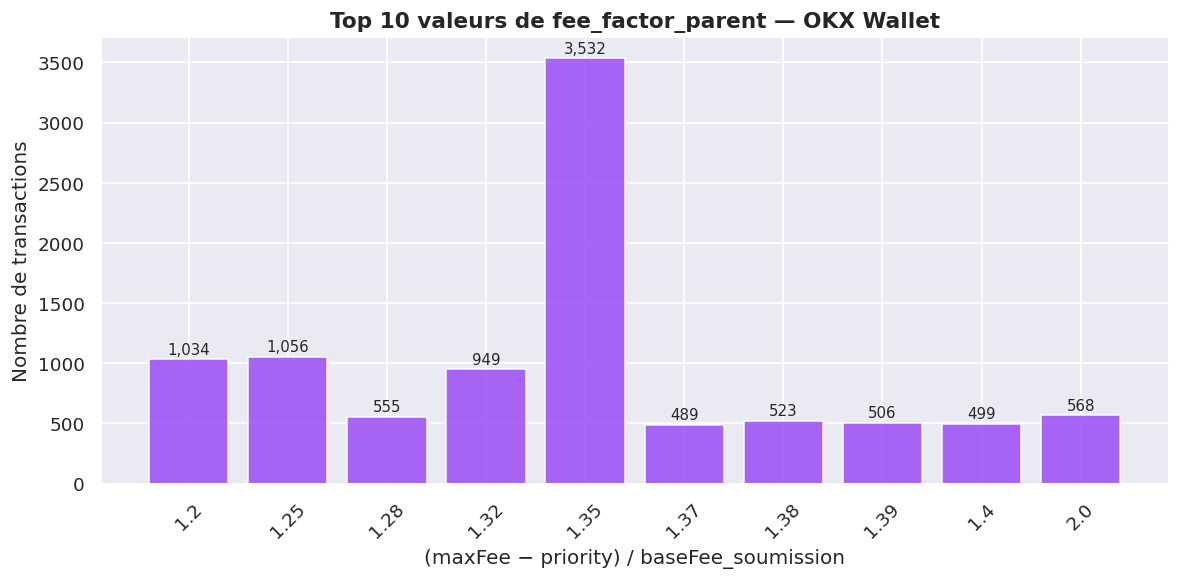


Top 10 valeurs de fee_factor_parent (arrondi à 2dp) :
fee_factor_parent
1.35    3532
1.25    1056
1.20    1034
1.32     949
2.00     568
1.28     555
1.38     523
1.39     506
1.40     499
1.37     489


In [3]:
ff_parent = df['fee_factor_parent'].dropna()
ff_parent_zoom = ff_parent[(ff_parent > 0.5) & (ff_parent <= 4.0)]

top_ffp = ff_parent_zoom.round(2).value_counts().head(10).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_ffp.index.astype(str), top_ffp.values, color='#9C4CF5', alpha=0.85)
ax.set_title('Top 10 valeurs de fee_factor_parent — OKX Wallet', fontsize=13, fontweight='bold')
ax.set_xlabel('(maxFee − priority) / baseFee_soumission')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_ffp.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 valeurs de fee_factor_parent (arrondi à 2dp) :")
print(ff_parent_zoom.round(2).value_counts().head(10).to_string())

## 3. Distribution du gas limit factor (`gasLimit / estimatedGas`)

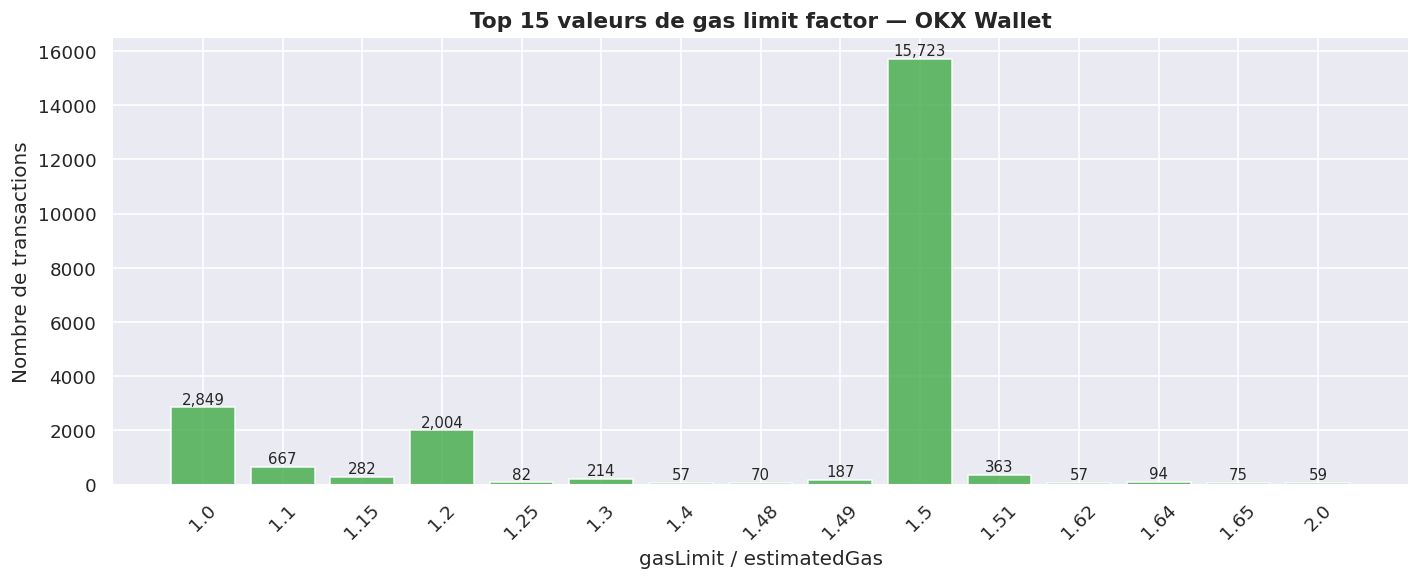


Top 15 valeurs de gas limit factor (arrondi à 2dp) :
gas_limit_factor
1.50    15723
1.00     2849
1.20     2004
1.10      667
1.51      363
1.15      282
1.30      214
1.49      187
1.64       94
1.25       82
1.65       75
1.48       70
2.00       59
1.62       57
1.40       57


In [4]:
glf = df['gas_limit_factor'].dropna()
glf_zoom = glf[(glf > 0.5) & (glf <= 5.0)]

top_glf = glf_zoom.round(2).value_counts().head(15).sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_glf.index.astype(str), top_glf.values, color='#4CAF50', alpha=0.85)
ax.set_title('Top 15 valeurs de gas limit factor — OKX Wallet', fontsize=13, fontweight='bold')
ax.set_xlabel('gasLimit / estimatedGas')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_glf.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 15 valeurs de gas limit factor (arrondi à 2dp) :")
print(glf_zoom.round(2).value_counts().head(15).to_string())

## 6. Résumé des signatures fingerprint

In [5]:
total = len(df)
eip1559 = df['fee_factor_parent'].notna().sum()

# Groupe principal : ffp ≈ 1.35
sig_135 = df[df['fee_factor_parent'].between(1.33, 1.37)]
sig_135_prio05 = sig_135[sig_135['max_priority_gwei'].between(0.45, 0.55)]

# Priority fee fixe à 0.5 Gwei
prio_05 = df[df['max_priority_gwei'].between(0.48, 0.52)]

print("═" * 55)
print("  OKX Wallet — Résumé des signatures fingerprint")
print("═" * 55)
print(f"  Total txs EIP-1559          : {eip1559:>7,}")
print()
print(f"  fee_factor_parent ≈ 1.35    : {len(sig_135):>7,}  ({len(sig_135)/eip1559*100:.1f}%)")
print(f"  ffp ≈ 1.35 ET prio ≈ 0.5   : {len(sig_135_prio05):>7,}  ({len(sig_135_prio05)/eip1559*100:.1f}%)")
print(f"  priority fee = 0.5 Gwei     : {len(prio_05):>7,}  ({len(prio_05)/eip1559*100:.1f}%)")
print()
print(f"  Médiane fee_factor_parent   : {df['fee_factor_parent'].dropna().median():.4f}")
print(f"  Mode fee_factor_parent (2dp): {df['fee_factor_parent'].dropna().round(2).mode()[0]:.2f}")
print(f"  Médiane priority fee        : {df['max_priority_gwei'].dropna().median():.4f} Gwei")
print(f"  Mode priority fee (2dp)     : {df['max_priority_gwei'].dropna().round(2).mode()[0]:.2f} Gwei")
print()
glf_clean = df['gas_limit_factor'].dropna()
glf_clean = glf_clean[(glf_clean > 0.5) & (glf_clean <= 5.0)]
print(f"  Médiane gas_limit_factor    : {glf_clean.median():.4f}")
print(f"  Mode gas_limit_factor (2dp) : {glf_clean.round(2).mode()[0]:.2f}")
print("═" * 55)

═══════════════════════════════════════════════════════
  OKX Wallet — Résumé des signatures fingerprint
═══════════════════════════════════════════════════════
  Total txs EIP-1559          :  25,125

  fee_factor_parent ≈ 1.35    :   4,922  (19.6%)
  ffp ≈ 1.35 ET prio ≈ 0.5   :   4,406  (17.5%)
  priority fee = 0.5 Gwei     :  13,839  (55.1%)

  Médiane fee_factor_parent   : 1.3500
  Mode fee_factor_parent (2dp): 1.35
  Médiane priority fee        : 0.5000 Gwei
  Mode priority fee (2dp)     : 0.50 Gwei

  Médiane gas_limit_factor    : 1.5000
  Mode gas_limit_factor (2dp) : 1.50
═══════════════════════════════════════════════════════
